In [4]:
# ── Imports ───────────────────────────────────────────────────────────────────
import duckdb
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ── Conexión a DuckDB ─────────────────────────────────────────────────────────
ROOT = Path().resolve().parent  # notebooks/ está un nivel adentro del repo
DB_PATH = ROOT / "data" / "processed" / "energia_colombia.duckdb"

con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"✅ Conectado: {DB_PATH}")

✅ Conectado: /home/danhzro/proyectos/alerta-energetica-colombia/data/processed/energia_colombia.duckdb


In [3]:
# ── Cobertura de todas las tablas ─────────────────────────────────────────────
tablas = [
    "demanda_sin", "precio_bolsa", "volumen_util",
    "porcentaje_embalse", "aportes_energia", "aportes_caudal",
    "clima_historico", "clima_pronostico",
]

print(f"{'Tabla':<25} {'Desde':<12} {'Hasta':<12} {'Registros':>10}")
print("─" * 62)

for tabla in tablas:
    row = con.execute(f"""
        SELECT
            MIN(fecha)::VARCHAR AS desde,
            MAX(fecha)::VARCHAR AS hasta,
            COUNT(*)            AS n
        FROM {tabla}
    """).fetchone()
    print(f"{tabla:<25} {row[0]:<12} {row[1]:<12} {row[2]:>10}")

Tabla                     Desde        Hasta         Registros
──────────────────────────────────────────────────────────────
demanda_sin               2023-01-01   2026-07-14         1291
precio_bolsa              2023-01-01   2026-07-13        30960
volumen_util              2023-01-01   2026-07-14        30600
porcentaje_embalse        2023-01-01   2026-07-14        30600
aportes_energia           2023-01-01   2026-07-14        52748
aportes_caudal            2023-01-01   2026-07-14        55801
clima_historico           2023-01-01   2026-08-17         7950
clima_pronostico          2026-08-18   2026-09-02           96


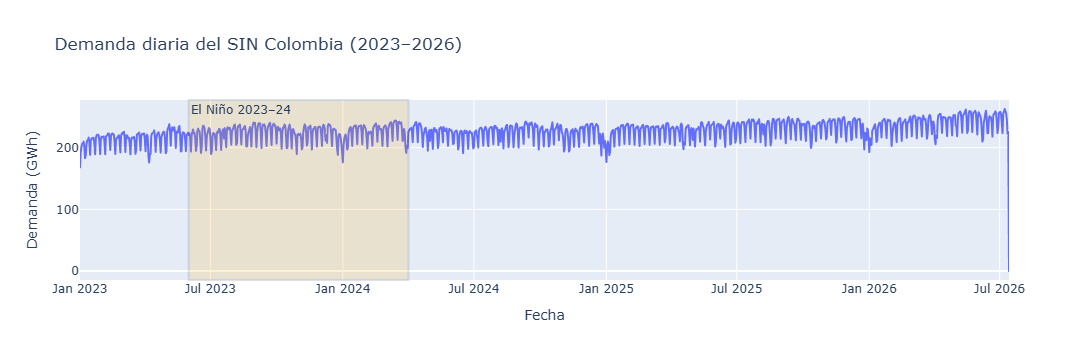


Estadísticas demanda (GWh):
count    1291.0
mean      226.8
std        16.5
min         0.1
25%       218.5
50%       229.5
75%       237.0
max       262.7
Name: valor_gwh, dtype: float64

Datos con demanda < 100 GWh (posibles errores):
          fecha  valor_gwh
1290 2026-07-14    0.09608


In [6]:
df_demanda = con.execute("""
    SELECT
        fecha,
        valor_kwh,
        valor_kwh / 1e6 AS valor_gwh,
        DAYOFWEEK(fecha) AS dia_semana
    FROM demanda_sin
    ORDER BY fecha
""").df()

df_demanda["fecha"] = pd.to_datetime(df_demanda["fecha"])

fig = px.line(
    df_demanda,
    x="fecha",
    y="valor_gwh",
    title="Demanda diaria del SIN Colombia (2023–2026)",
    labels={"fecha": "Fecha", "valor_gwh": "Demanda (GWh)"},
)

fig.add_vrect(
    x0="2023-06-01", x1="2024-04-01",
    fillcolor="orange", opacity=0.15,
    annotation_text="El Niño 2023–24",
    annotation_position="top left",
)

fig.update_layout(hovermode="x unified")
fig.show()

print(f"\nEstadísticas demanda (GWh):")
print(df_demanda["valor_gwh"].describe().round(1))

# Ver el dato sospechoso de 0
print(f"\nDatos con demanda < 100 GWh (posibles errores):")
print(df_demanda[df_demanda["valor_gwh"] < 100][["fecha", "valor_gwh"]])

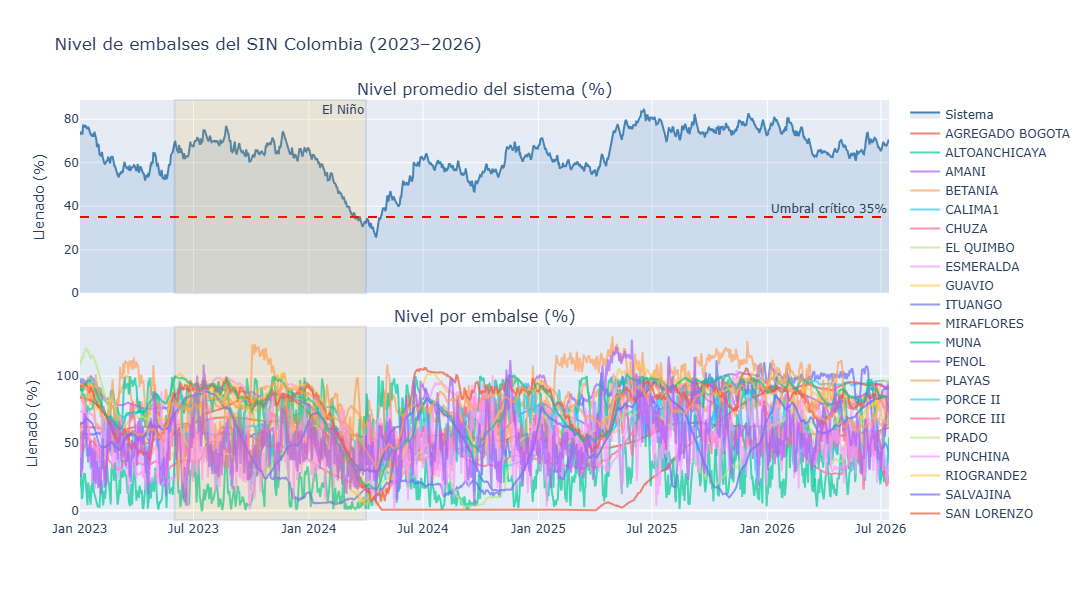


Mínimo histórico del sistema:
fecha          2024-04-17 00:00:00
pct_sistema               25.65175
Name: 472, dtype: object


In [7]:
# ── Porcentaje de llenado del sistema ─────────────────────────────────────────
df_embalses = con.execute("""
    SELECT
        fecha,
        embalse,
        porcentaje * 100 AS pct  -- convertir a porcentaje 0-100
    FROM porcentaje_embalse
    ORDER BY fecha, embalse
""").df()

df_embalses["fecha"] = pd.to_datetime(df_embalses["fecha"])

# Promedio del sistema (todos los embalses agregados)
df_sistema = df_embalses.groupby("fecha")["pct"].mean().reset_index()
df_sistema.columns = ["fecha", "pct_sistema"]

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("Nivel promedio del sistema (%)",
                                    "Nivel por embalse (%)"),
                    vertical_spacing=0.08)

# Panel superior: promedio del sistema
fig.add_trace(
    go.Scatter(x=df_sistema["fecha"], y=df_sistema["pct_sistema"],
               name="Sistema", line=dict(color="steelblue", width=2),
               fill="tozeroy", fillcolor="rgba(70,130,180,0.15)"),
    row=1, col=1
)

# Línea de alerta crítica (35%)
fig.add_hline(y=35, line_dash="dash", line_color="red",
              annotation_text="Umbral crítico 35%", row=1, col=1)

# Panel inferior: cada embalse
for embalse in df_embalses["embalse"].unique():
    df_e = df_embalses[df_embalses["embalse"] == embalse]
    fig.add_trace(
        go.Scatter(x=df_e["fecha"], y=df_e["pct"],
                   name=embalse, mode="lines", opacity=0.7),
        row=2, col=1
    )

# Zona El Niño en ambos paneles
for row in [1, 2]:
    fig.add_vrect(x0="2023-06-01", x1="2024-04-01",
                  fillcolor="orange", opacity=0.12,
                  annotation_text="El Niño" if row == 1 else "",
                  row=row, col=1)

fig.update_layout(
    title="Nivel de embalses del SIN Colombia (2023–2026)",
    height=600,
    hovermode="x unified",
)
fig.update_yaxes(title_text="Llenado (%)", row=1, col=1)
fig.update_yaxes(title_text="Llenado (%)", row=2, col=1)
fig.show()

print(f"\nMínimo histórico del sistema:")
idx_min = df_sistema["pct_sistema"].idxmin()
print(df_sistema.loc[idx_min])

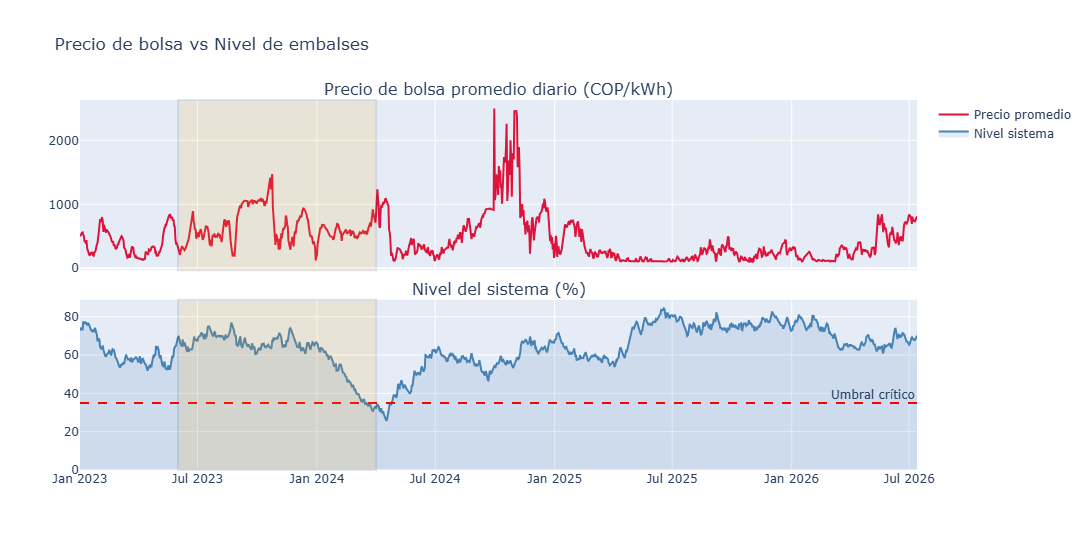


Correlación precio vs nivel sistema: -0.366

Top 5 días con precio más alto:
     fecha  precio_promedio  pct_sistema
2024-09-30      2498.804070    54.247174
2024-11-01      2459.239950    55.243217
2024-11-03      2459.239950    57.580826
2024-10-31      2457.103607    54.014043
2024-11-02      2451.801200    55.975826


In [8]:
# ── Precio de bolsa diario (promedio) vs nivel de embalses ───────────────────
df_precio = con.execute("""
    SELECT
        fecha,
        AVG(valor_cop_kwh) AS precio_promedio,
        MAX(valor_cop_kwh) AS precio_max
    FROM precio_bolsa
    GROUP BY fecha
    ORDER BY fecha
""").df()

df_precio["fecha"] = pd.to_datetime(df_precio["fecha"])

# Unir con nivel del sistema
df_merged = df_precio.merge(df_sistema, on="fecha", how="inner")

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "Precio de bolsa promedio diario (COP/kWh)",
        "Nivel del sistema (%)"
    ),
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(x=df_merged["fecha"], y=df_merged["precio_promedio"],
               name="Precio promedio", line=dict(color="crimson")),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df_merged["fecha"], y=df_merged["pct_sistema"],
               name="Nivel sistema", line=dict(color="steelblue"),
               fill="tozeroy", fillcolor="rgba(70,130,180,0.15)"),
    row=2, col=1
)

fig.add_hline(y=35, line_dash="dash", line_color="red",
              annotation_text="Umbral crítico", row=2, col=1)

for row in [1, 2]:
    fig.add_vrect(x0="2023-06-01", x1="2024-04-01",
                  fillcolor="orange", opacity=0.12, row=row, col=1)

fig.update_layout(
    title="Precio de bolsa vs Nivel de embalses",
    height=550,
    hovermode="x unified",
)
fig.show()

# Correlación
corr = df_merged[["precio_promedio", "pct_sistema"]].corr()
print(f"\nCorrelación precio vs nivel sistema: {corr.loc['precio_promedio','pct_sistema']:.3f}")
print(f"\nTop 5 días con precio más alto:")
print(df_merged.nlargest(5, "precio_promedio")[["fecha","precio_promedio","pct_sistema"]].to_string(index=False))

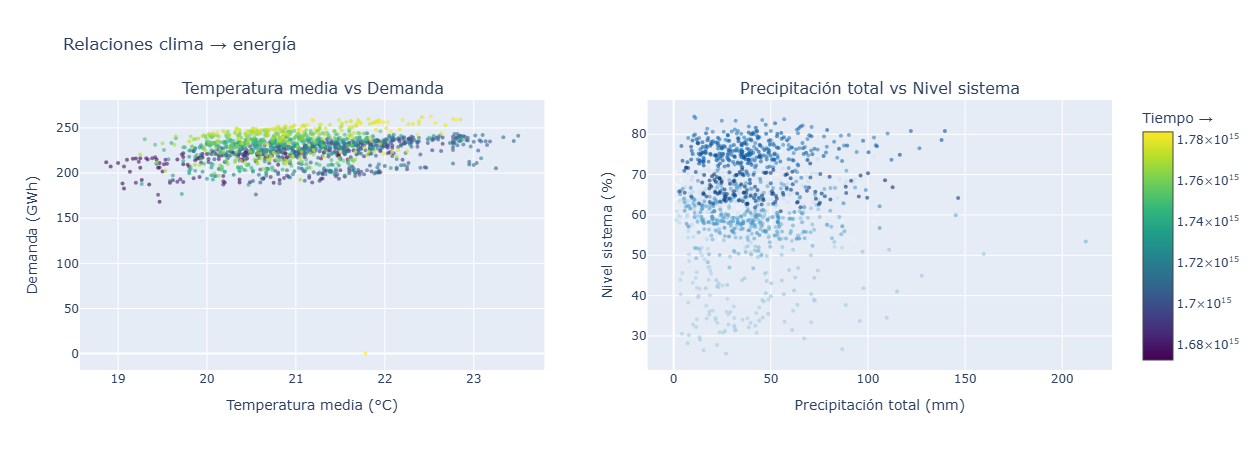

Correlación temperatura vs demanda:       0.244
Correlación precipitación vs nivel sistema: 0.028


In [9]:
# ── Clima vs Demanda ──────────────────────────────────────────────────────────
df_clima = con.execute("""
    SELECT
        fecha,
        AVG(temp_mean)     AS temp_media,
        AVG(temp_max)      AS temp_max,
        SUM(precipitacion) AS precip_total
    FROM clima_historico
    GROUP BY fecha
    ORDER BY fecha
""").df()

df_clima["fecha"] = pd.to_datetime(df_clima["fecha"])

# Unir clima + demanda
df_clima_dem = df_clima.merge(
    df_demanda[["fecha", "valor_gwh"]], on="fecha", how="inner"
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Temperatura media vs Demanda",
        "Precipitación total vs Nivel sistema"
    )
)

# Scatter temperatura vs demanda
fig.add_trace(
    go.Scatter(
        x=df_clima_dem["temp_media"],
        y=df_clima_dem["valor_gwh"],
        mode="markers",
        marker=dict(
            color=df_clima_dem["fecha"].astype("int64"),
            colorscale="Viridis",
            size=4,
            opacity=0.6,
            showscale=True,
            colorbar=dict(title="Tiempo →"),
        ),
        name="Temp vs Demanda",
        text=df_clima_dem["fecha"].dt.strftime("%Y-%m-%d"),
        hovertemplate="Fecha: %{text}<br>Temp: %{x:.1f}°C<br>Demanda: %{y:.1f} GWh",
    ),
    row=1, col=1
)

# Scatter precipitación vs nivel sistema
df_precip_niv = df_clima.merge(df_sistema, on="fecha", how="inner")

fig.add_trace(
    go.Scatter(
        x=df_precip_niv["precip_total"],
        y=df_precip_niv["pct_sistema"],
        mode="markers",
        marker=dict(
            color=df_precip_niv["fecha"].astype("int64"),
            colorscale="Blues",
            size=4,
            opacity=0.6,
        ),
        name="Precip vs Nivel",
        text=df_precip_niv["fecha"].dt.strftime("%Y-%m-%d"),
        hovertemplate="Fecha: %{text}<br>Precip: %{x:.1f}mm<br>Nivel: %{y:.1f}%",
    ),
    row=1, col=2
)

fig.update_xaxes(title_text="Temperatura media (°C)", row=1, col=1)
fig.update_yaxes(title_text="Demanda (GWh)", row=1, col=1)
fig.update_xaxes(title_text="Precipitación total (mm)", row=1, col=2)
fig.update_yaxes(title_text="Nivel sistema (%)", row=1, col=2)

fig.update_layout(
    title="Relaciones clima → energía",
    height=450,
    showlegend=False,
)
fig.show()

# Correlaciones
corr_temp = df_clima_dem[["temp_media","valor_gwh"]].corr().loc["temp_media","valor_gwh"]
corr_precip = df_precip_niv[["precip_total","pct_sistema"]].corr().loc["precip_total","pct_sistema"]
print(f"Correlación temperatura vs demanda:       {corr_temp:.3f}")
print(f"Correlación precipitación vs nivel sistema: {corr_precip:.3f}")

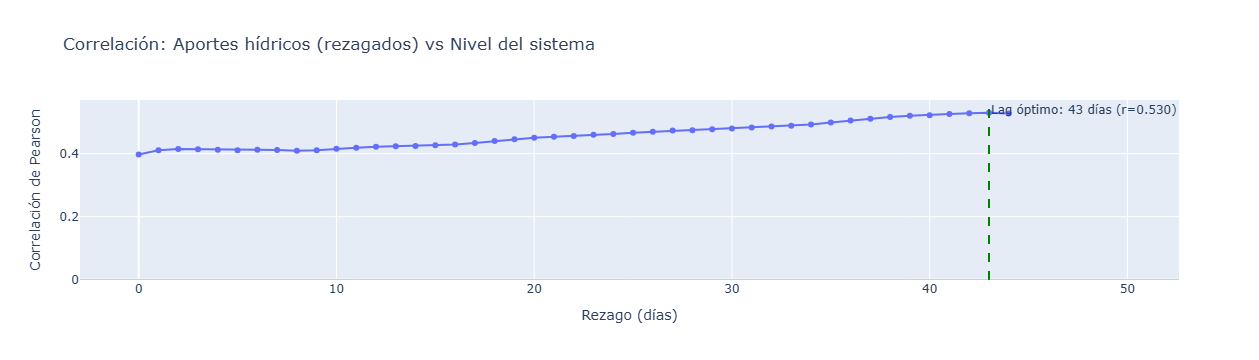

Lag óptimo: 43 días
Correlación máxima: 0.530

Top 5 lags:
 lag_dias  correlacion
       43     0.529937
       42     0.528515
       44     0.527810
       41     0.525737
       40     0.522312


In [11]:
# ── Aportes hídricos agregados del sistema ────────────────────────────────────
df_aportes = con.execute("""
    SELECT
        fecha,
        SUM(valor_kwh) / 1e6 AS aportes_gwh
    FROM aportes_energia
    GROUP BY fecha
    ORDER BY fecha
""").df()

df_aportes["fecha"] = pd.to_datetime(df_aportes["fecha"])

# Unir aportes + nivel sistema
df_hidrico = df_aportes.merge(df_sistema, on="fecha", how="inner")

# Calcular correlaciones con diferentes rezagos
lags = range(0, 45)
correlaciones = []

for lag in lags:
    df_lag = df_hidrico.copy()
    df_lag["aportes_lag"] = df_lag["aportes_gwh"].shift(lag)
    corr = df_lag[["aportes_lag", "pct_sistema"]].corr().loc["aportes_lag", "pct_sistema"]
    correlaciones.append({"lag_dias": lag, "correlacion": corr})

df_corr = pd.DataFrame(correlaciones)

# Gráfica de correlación por rezago
fig = px.line(
    df_corr,
    x="lag_dias",
    y="correlacion",
    title="Correlación: Aportes hídricos (rezagados) vs Nivel del sistema",
    labels={"lag_dias": "Rezago (días)", "correlacion": "Correlación de Pearson"},
    markers=True,
)

# Marcar el lag óptimo
lag_optimo = df_corr.loc[df_corr["correlacion"].idxmax(), "lag_dias"]
corr_max = df_corr["correlacion"].max()

fig.add_vline(
    x=lag_optimo, line_dash="dash", line_color="green",
    annotation_text=f"Lag óptimo: {lag_optimo} días (r={corr_max:.3f})",
    annotation_position="top right",
)
fig.add_hline(y=0, line_color="gray", line_width=0.5)

fig.update_layout(hovermode="x unified")
fig.show()

print(f"Lag óptimo: {lag_optimo} días")
print(f"Correlación máxima: {corr_max:.3f}")
print(f"\nTop 5 lags:")
print(df_corr.nlargest(5, "correlacion").to_string(index=False))

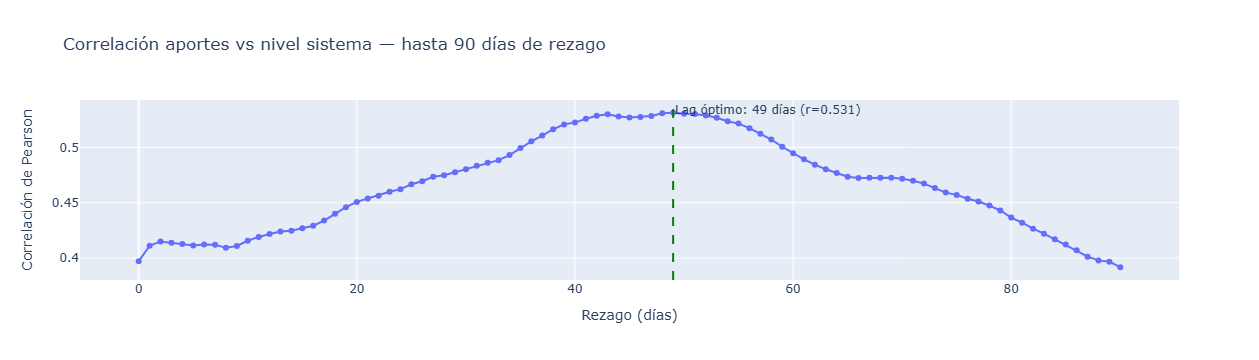

Lag óptimo extendido: 49 días, r=0.531


In [12]:
lags_ext = range(0, 91)
correlaciones_ext = []

for lag in lags_ext:
    df_lag = df_hidrico.copy()
    df_lag["aportes_lag"] = df_lag["aportes_gwh"].shift(lag)
    corr = df_lag[["aportes_lag", "pct_sistema"]].corr().loc["aportes_lag", "pct_sistema"]
    correlaciones_ext.append({"lag_dias": lag, "correlacion": corr})

df_corr_ext = pd.DataFrame(correlaciones_ext)

fig = px.line(
    df_corr_ext,
    x="lag_dias",
    y="correlacion",
    title="Correlación aportes vs nivel sistema — hasta 90 días de rezago",
    labels={"lag_dias": "Rezago (días)", "correlacion": "Correlación de Pearson"},
    markers=True,
)

lag_optimo_ext = df_corr_ext.loc[df_corr_ext["correlacion"].idxmax(), "lag_dias"]
corr_max_ext = df_corr_ext["correlacion"].max()

fig.add_vline(
    x=lag_optimo_ext, line_dash="dash", line_color="green",
    annotation_text=f"Lag óptimo: {lag_optimo_ext} días (r={corr_max_ext:.3f})",
    annotation_position="top right",
)

fig.update_layout(hovermode="x unified")
fig.show()

print(f"Lag óptimo extendido: {lag_optimo_ext} días, r={corr_max_ext:.3f}")

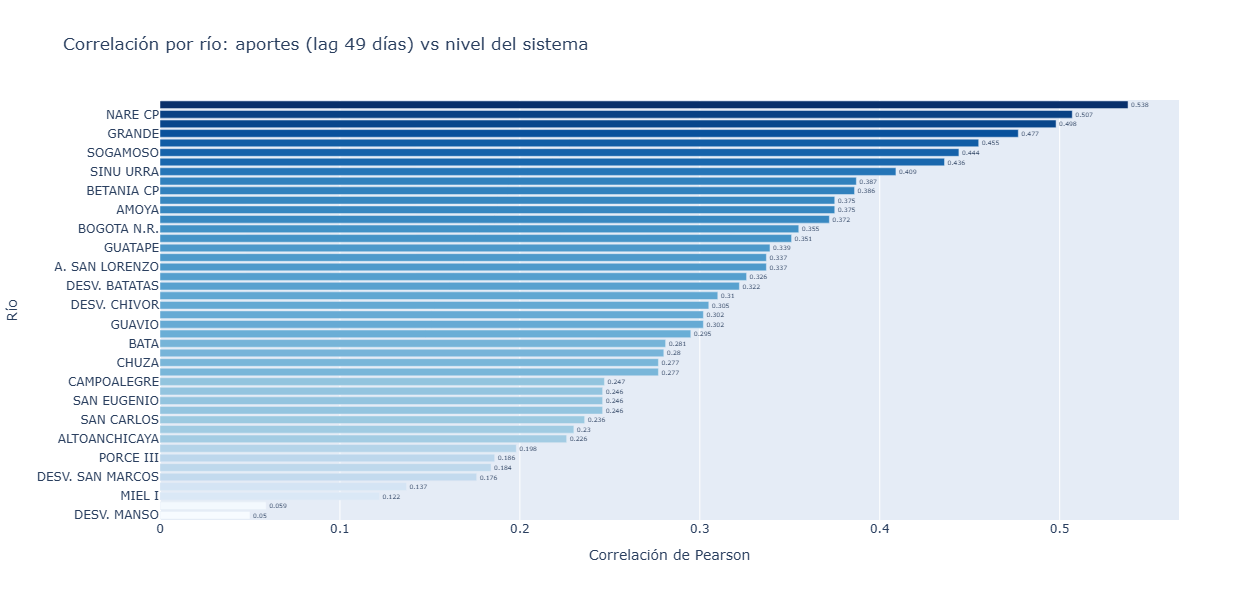

                      rio  correlacion_lag49  aporte_medio_gwh
         ESCUELA DE MINAS              0.538              11.6
                  NARE CP              0.507               5.8
               QUEBRADONA              0.498               0.1
                   GRANDE              0.477               9.9
                     NARE              0.455              15.5
                 SOGAMOSO              0.444              13.8
                GUADALUPE              0.436               5.1
                SINU URRA              0.409               4.1
               CONCEPCION              0.387               1.9
               BETANIA CP              0.386               2.5
                    AMOYA              0.375               2.2
                  ITUANGO              0.375              32.4
                PORCE2 CP              0.372               3.7
              BOGOTA N.R.              0.355              14.0
            CARLOS LLERAS              0.351           

In [13]:
# ── Correlación por río individual (lag=49 días) ──────────────────────────────
df_rios = con.execute("""
    SELECT
        fecha,
        rio,
        valor_kwh / 1e6 AS aportes_gwh
    FROM aportes_energia
    ORDER BY fecha, rio
""").df()

df_rios["fecha"] = pd.to_datetime(df_rios["fecha"])

rios = df_rios["rio"].unique()
resultados_rios = []

for rio in rios:
    df_rio = df_rios[df_rios["rio"] == rio][["fecha", "aportes_gwh"]].copy()
    df_rio = df_rio.merge(df_sistema, on="fecha", how="inner")
    
    # Lag óptimo encontrado: 49 días
    df_rio["aportes_lag49"] = df_rio["aportes_gwh"].shift(49)
    df_rio = df_rio.dropna()
    
    if len(df_rio) < 100:  # ignorar ríos con pocos datos
        continue
    
    corr = df_rio[["aportes_lag49", "pct_sistema"]].corr().loc["aportes_lag49", "pct_sistema"]
    media_aportes = df_rio["aportes_gwh"].mean()
    
    resultados_rios.append({
        "rio": rio,
        "correlacion_lag49": round(corr, 3),
        "aporte_medio_gwh": round(media_aportes, 1),
    })

df_rios_corr = pd.DataFrame(resultados_rios).sort_values("correlacion_lag49", ascending=False)

fig = px.bar(
    df_rios_corr,
    x="correlacion_lag49",
    y="rio",
    orientation="h",
    title="Correlación por río: aportes (lag 49 días) vs nivel del sistema",
    labels={"correlacion_lag49": "Correlación de Pearson", "rio": "Río"},
    color="correlacion_lag49",
    color_continuous_scale="Blues",
    text="correlacion_lag49",
)

fig.update_traces(textposition="outside")
fig.update_layout(height=600, coloraxis_showscale=False, yaxis={"categoryorder": "total ascending"})
fig.show()

print(df_rios_corr.to_string(index=False))

In [14]:
# Buscar Magdalena y Cauca en los datos
df_buscar = con.execute("""
    SELECT DISTINCT rio
    FROM aportes_energia
    WHERE LOWER(rio) LIKE '%magdalena%'
       OR LOWER(rio) LIKE '%cauca%'
       OR LOWER(rio) LIKE '%mag%'
    ORDER BY rio
""").df()

print(df_buscar)

               rio
0  CAUCA SALVAJINA
